In [1]:
using CMPSKit, Plots, OptimKit, KrylovKit, LinearAlgebra, LaTeXStrings
using CMPSKit: YangGaudinCMPS, groundstate_unconstrained

In [ ]:
# Hsingle(c, μ) = ∫(∂ψ̂' * ∂ψ̂ - μ * ψ̂' * ψ̂ + c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
Hsingle(c, μ) = ∫(2 * ∂ψ̂' * ∂ψ̂ - 2 * μ * ψ̂' * ψ̂ + 4 * c * (ψ̂')^2 * ψ̂^2, (-Inf, +Inf));
Hcoupled(c, μ) = ∫(
    (∂ψ̂₁' * ∂ψ̂₁ - μ * ψ̂₁' * ψ̂₁ + c * (ψ̂₁')^2 * ψ̂₁^2 +
     ∂ψ̂₂' * ∂ψ̂₂ - μ * ψ̂₂' * ψ̂₂ + c * (ψ̂₂')^2 * ψ̂₂^2 +
     2 * c * (ψ̂₁') * (ψ̂₂') * ψ̂₂ * ψ̂₁), (-Inf, +Inf));

find_groundstate (generic function with 2 methods)

In [63]:
c, μ = 10., 5.
tol = 1e-10
HLL = Hsingle(c, μ)

Ds = [4]
stateLL = find_groundstate(Ds, HLL, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
D = maximum(Ds)
println("Energy density: ", expval(HLL.h, stateLL)[], "\n Particle density: ", expval(ψ̂' * ψ̂, stateLL)[], "\n Order parameter: ", expval(ψ̂, stateLL)[])

Optimizing D=4


┌ Info: YangGaudinCMPS ground state: initialization with e = 1850.799376268042
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:106
┌ Info: YangGaudinCMPS ground state: converged after 167 iterations: e = -2.734747817523, ‖∇e‖ = 2.7323e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/yanggaudin/groundstate.jl:118


D = 4 | YangGaudinCMPS{Constant{Matrix{Float64}}, 1}
  0.290086 seconds (499.10 k allocations: 28.911 MiB, 5.27% gc time)
---------------
Energy density: -2.7347478175232007
 Particle density: 0.43244359486924244
 Order parameter: -0.4386898377583038


In [64]:
stateCLL = InfiniteCMPS(stateLL.Q, (stateLL.Rs[1], stateLL.Rs[1]));
HCLL = Hcoupled(c, μ)
println("Energy density: ", expval(HCLL.h, stateCLL)[], "\nParticle density: ", expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[], "\nDensity imbalance: ", expval(ψ̂₁' * ψ̂₁ - ψ̂₂' * ψ̂₂, stateCLL)[])

Energy density: -2.7347478175232296
Particle density: 0.8648871897384841
Density imbalance: 0.0


In [91]:
# canonical basis
function projection_matrix(D, M)
    dim_in = D^2 + D      # input: E (DxD) + F (D)
    dim_out = 2 * D^2     # output: W1, W2 (both DxD)
    P = zeros(ComplexF64, dim_out, dim_in)

    for j in 1:dim_in
        e = zeros(Float64, dim_in)
        e[j] = 1.0

        E = reshape(view(e, 1:D^2), D, D)
        F = view(e, D^2+1:dim_in)

        W1 = E
        W2 = E + M * Diagonal(F) / M

        P[:, j] = vcat(vec(W1), vec(W2))
    end

    return Matrix(qr(P).Q) # moves to an orthogonal projection
end

# canonical basis
function excitation_matrix(Heff, D)
    dim = 2 * D^2
    M = zeros(ComplexF64, dim, dim)

    for j in 1:dim
        e = zeros(ComplexF64, dim)
        e[j] = 1.0
        W1 = reshape(view(e, 1:D^2), D, D)
        W2 = reshape(view(e, D^2+1:dim), D, D)
        W1p, W2p = Heff((Constant(W1), Constant(W2)))
        M[:, j] = vcat(vec(W1p[]), vec(W2p[]))
    end

    return M
end

function excitation_matrix_constrained(Heff, M)
    D = size(M, 1) # R = MDᵣ/M
    H = excitation_matrix(Heff, D)
    P = projection_matrix(D, M)

    P' * H * P, P
end

excitation_matrix_constrained (generic function with 1 method)

In [86]:
nvals = 3
ρ = expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCLL)[]
ps = range(-2π * ρ, 2π * ρ, 11)
trivial_spectrum = zeros(ComplexF64, length(ps), nvals);
trivial_excitations = [[] for _ in eachindex(ps)]

Threads.@threads for idx in eachindex(ps)
    space = InfiniteCMPSExcitationSpace(ps[idx], stateCLL, stateCLL)
    Heff, P = excitation_matrix_constrained(excitation_operator(HCLL, space), eigen(stateCLL.Rs[1][]).vectors)
    vals, vecs = eigsolve(Heff, rand(D^2 + D), nvals, :SR)
    trivial_spectrum[idx, :] .= vals[1:nvals]
    trivial_excitations[idx] = map(vecs[1:nvals]) do vec
        Ws = P * vec
        D = floor(Int, sqrt(length(Ws) ÷ 2))
        W₁ = reshape(view(Ws, 1:D^2), D, D)
        W₂ = reshape(view(Ws, (D^2+1):2*D^2), D, D)
        return (W₁, W₂)
    end
end

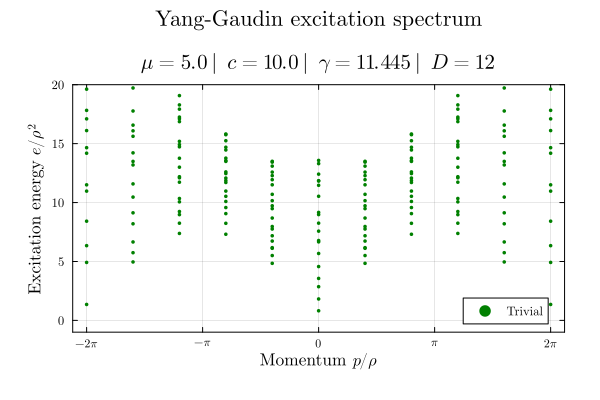

In [32]:
scatter(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2, lab=permutedims(["Trivial"; fill("", nvals - 1)]), ms=2, c=:green, markerstrokewidth=0)
plot!(xtick=pitick(-2π, 2π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Yang-Gaudin excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm, ylim=[-1, 20])

In [74]:
nvals = 4
pts = range(-2π * ρ, 2π * ρ, 3)
topo_spectrum = zeros(ComplexF64, length(pts), nvals);
topo_excitations = [[] for _ in eachindex(pts)]

ρr = rightenv(stateCLL)[1][]
u1charges = zeros(ComplexF64, length(pts), nvals, 2)

θs = [0, 2π] # difference, sum
stateCLL_left = InfiniteCMPS((1 + 0im) * stateCLL.Q, ntuple(i -> (1. + 0im) * stateCLL.Rs[i], length(stateCLL.Rs)))
stateCLL_right = InfiniteCMPS(stateCLL_left.Q, ntuple(i -> exp(0.5im * (θs[2] + (-1)^i * θs[1])) * stateCLL_left.Rs[i], length(stateCLL_left.Rs)))

Threads.@threads for idx in eachindex(pts)
    space = InfiniteCMPSExcitationSpace(pts[idx], stateCLL_left, stateCLL_right)
    Heff, P = excitation_matrix_constrained(excitation_operator(HCLL, space), eigen(stateCLL.Rs[1][]).vectors)
    vals, vecs = eigsolve(Heff, rand(D^2 + D), nvals, :SR)
    topo_spectrum[idx, :] .= vals[1:nvals]
    topo_excitations[idx] = map(vecs[1:nvals]) do vec
        Ws = P * vec
        D = floor(Int, sqrt(length(Ws) ÷ 2))
        W₁ = reshape(view(Ws, 1:D^2), D, D)
        W₂ = reshape(view(Ws, (D^2+1):2*D^2), D, D)
        return (W₁, W₂)
    end

    for (i, Ws) in enumerate(topo_excitations[idx])
        # ∫⟨ρ⟩ - ⟨ρ₀⟩ = N -> particle/hole charge
        Hψ = excitation_operator(∫(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, (-Inf, Inf)), space)
        ψW = getindex.(Hψ((Constant(Ws[1]), Constant(Ws[2]))))
        u1charges[idx, i, 1] = tr(ψW[1] * ρr * Ws[1]')
        u1charges[idx, i, 2] = tr(ψW[2] * ρr * Ws[2]')
    end

    # println("Finished $idx - $(pts[idx])")
end

In [9]:
title_latex = "Yang-Gaudin excitation spectrum\n\n" *
              L"\mu=%$μ \ | \ c=%$c \ | \ \gamma=%$(round(c/ρ, digits=3)) \ | \ D=%$D \ | \theta_+=" *
              piticklabel(rationalize(last(θs) / π), Val(:latex)) *
              L" \ | \theta_-=" *
              piticklabel(rationalize(first(θs) / π), Val(:latex))

plt = scatter(pts ./ ρ, real.(topo_spectrum) ./ ρ^2, lab=permutedims(["Topological"; fill("", nvals - 1)]), ms=2.5, marker_z=real.(dropdims(sum(u1charges, dims=3), dims=3)), markerstrokewidth=0, colorbar=true, c=:berlin)
plot!(xtick=pitick(-2π, 2π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title=title_latex, margins=7Plots.mm, size=(900, 500))
savefig("../../data/yg_topological_excitations_mu=$(μ)_c=$(c)_D=$(D)_tp=$(round(θs[2], digits=3))_tm=$(round(θs[1], digits=3)).png")
plt

UndefVarError: UndefVarError: `ρ` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

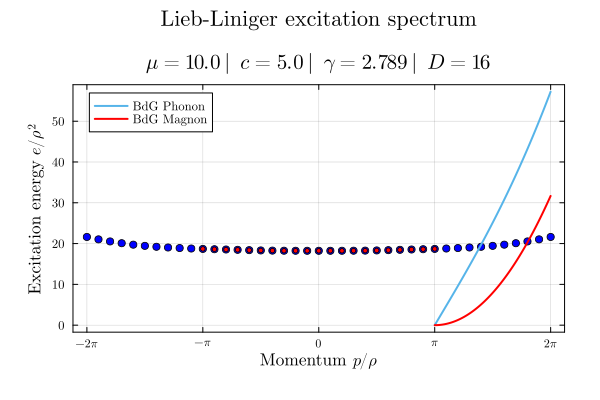

In [12]:
let
    charges = dropdims(sum(u1charges, dims=3), dims=3)
    domain_idx = [searchsortedfirst(pts, -π * ρ), searchsortedfirst(pts, π * ρ)]
    # lowest energy in -πρ ≤ p ≤ πρ
    hole_spectrum = real.(topo_spectrum[domain_idx[1]:domain_idx[2], 1])

    # positive particle number wrt ground state
    particle_spectrum = map(1:size(charges, 1)) do rowidx
        idx = findfirst(!=(0), real.(charges)[rowidx, :])
        isnothing(idx) && return missing
        real(topo_spectrum[rowidx, idx])
    end

    scatter(pts ./ ρ, particle_spectrum, c=:blue)
    plot!(k -> sqrt((ρ * (k - π))^4 + 8 * c * ρ * ((ρ * (k - π))^2)), π:0.01:2π, lw=2, lab="BdG Phonon")
    plot!(k -> (ρ * (k - π))^2, π:0.01:2π, lw=2, lab="BdG Magnon", c=:red)
    scatter!(pts[domain_idx[1]:domain_idx[2]] ./ ρ, hole_spectrum, c=:red, ms=2.5)
    plot!(xtick=pitick(-2π, 2π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Lieb-Liniger excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm)
end

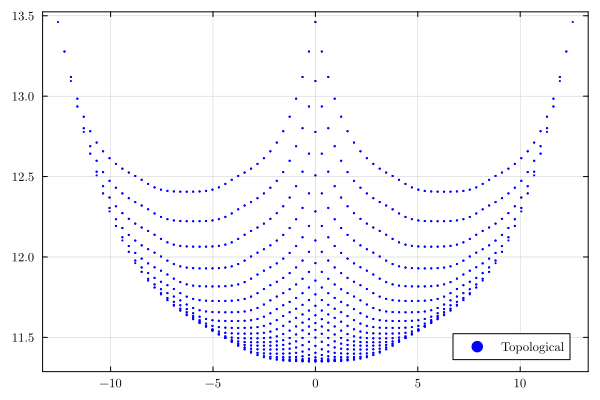

In [13]:
spinflip_excitations = collect(Iterators.flatten(zip.(Ref(pts), eachcol(real.(topo_spectrum)))))
spinflip_combinations = collect(zip(vec(first.(spinflip_excitations) .+ first.(spinflip_excitations)'), vec(last.(spinflip_excitations) .+ last.(spinflip_excitations)')));

# filter!(((k, E),) -> (E < 10 * ρ^2), spinflip_combinations)
scatter(first.(spinflip_combinations) ./ ρ, last.(spinflip_combinations) ./ ρ^2, lab=permutedims(["Topological"; fill("", nvals - 1)]), ms=1.2, c=:blue, markerstrokewidth=0);
#scatter!(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2, lab=permutedims(["Trivial"; fill("", nvals - 1)]), ms=2, c=:red, markerstrokewidth=0)

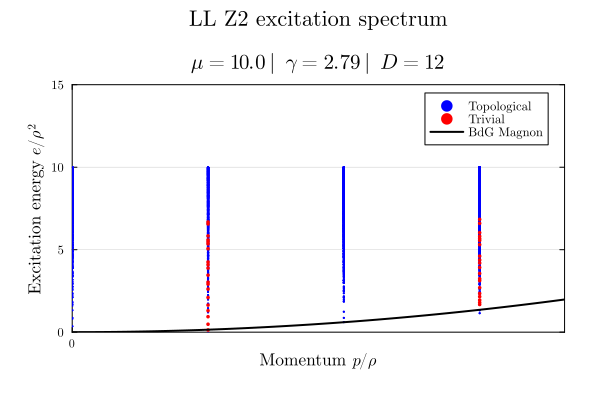

In [ ]:
scatter!(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2, lab=permutedims(["Trivial"; fill("", nvals - 1)]), ms=2, c=:red, markerstrokewidth=0)
plot!(k -> (ρ * (k))^2, 0:0.01:2π, lw=2, lab="BdG Magnon", c=:black)
plot!(xtick=pitick(0, π / 4, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="LL Z2 excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm, ylims=[0, 15], xlims=[0, π / 4])

## Checks

In [15]:
# let # gradients
#     ΨL, = leftgauge(stateCLL)
#     ρR, λ, info_ρR = rightenv(ΨL)
#     ρL = one(ρR)
#     rmul!(ρR, 1 / tr(ρR[]))

#     CMPSKit.gradient(HCLL, (ΨL, ρL, ρR))[1][] |> display
#     CMPSKit.gradient(HCLL, (ΨL, ρL, ρR))[2][1][] |> display
#     norm(CMPSKit.gradient(HCLL, (ΨL, ρL, ρR))[2][1][] + CMPSKit.gradient(HCLL, (ΨL, ρL, ρR))[2][2][])
# end

In [16]:
# let # earlier naive (incorrect) approach
#     stateL = find_groundstate(Ds, HLL, InfiniteCMPS, optalg=LBFGS(80; verbosity=0, maxiter=7000, gradtol=tol), gradtol=tol)
#     stateCL = InfiniteCMPS(stateL.Q, (stateL.Rs[1], stateL.Rs[1]))
#     HCL = Hcoupled(c, μ)
#     println("Energy density: ", expval(HCL.h, stateCL)[], "\n Particle density: ", expval(ψ̂₁' * ψ̂₁ + ψ̂₂' * ψ̂₂, stateCL)[])

#     ΨL, = leftgauge(stateCL)
#     ρR, λ, info_ρR = rightenv(ΨL)
#     ρL = one(ρR)
#     rmul!(ρR, 1 / tr(ρR[]))
#     println(norm(CMPSKit.gradient(HCL, (ΨL, ρL, ρR))[1][]))
#     norm(CMPSKit.gradient(HCL, (ΨL, ρL, ρR))[2][1][] + CMPSKit.gradient(HCL, (ΨL, ρL, ρR))[2][2][])
# end

In [ ]:
# function excitation_operator_transformed(Ψ::InfiniteCMPS, Heff)
#     R = first(Ψ.Rs)[]
#     D, M = eigen(R)

        # P†P won't necessarily be positive definite
#     function f((X, dD₁, dD₂))
#         Wi₁ = Constant(M * (X .* D - X .* D' + Diagonal(dD₁)) / M)
#         Wi₂ = Constant(M * (X .* D - X .* D' + Diagonal(dD₂)) / M)
#         Wf₁, Wf₂ = Heff((Wi₁, Wi₂))

#         MW₁M = (M\Wf₁*M)[]
#         MW₂M = (M\Wf₂*M)[]

#         dDf₁ = diag(MW₁M)
#         dDf₂ = diag(MW₂M)

#         Xf = (MW₁M - Diagonal(dDf₁)) ./ (transpose(D) .- D)   # elementwise division
#         Xf[diagind(Xf)] .= 0           # set diagonal arbitrarily

#         Xf1 = (MW₂M - Diagonal(dDf₂)) ./ (transpose(D) .- D)   # elementwise division
#         Xf1[diagind(Xf1)] .= 0           # set diagonal arbitrarily

#         return (Xf, dDf₁, dDf₂)
#     end
# end